In [1]:
# Homework Assignment 6

# Homework Assignment 6 builds upon Homework Assignment 5
# anova
# Statistics concept:
# You are required to conduct 1-way anova test for asset_return_df,
## the choice of standard or welch anava test depends on the outcome of homoscedasticity test of the asset returns.
# You are then require to conduct the post hoc pairwise tests based on the p_value of the anova test,
## all three alternatives (two-sided, great, less) should be tested,'

# You are required to conduct 1-way anova test for sample_list_stratified,
## the choice of standard or welch anava test depends on the outcome of homoscedasticity test of the sample returns.
# You are then require to conduct the post hoc pairwise tests based on the p_value of the anova test,
## all three alternatives (two-sided, great, less) should be tested.

# I expect you to write all functionalities in functions, as this is an "applied" course
## and I hope you can also improve you Python coding skills through working on the homework assignments

# I provide fully functional sample code, but please do write your own code.
# Happy coding!

In [2]:
import numpy as np
import pandas as pd
import statistics
from statsmodels import robust
from scipy import stats
from scipy.stats import t, sem, levene
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
import pingouin as pg
from pingouin import ttest
import itertools
from IPython.display import display


In [3]:
# Please enter you code for the funtion that generates the "asset_return_df" dataframe.
# I provide fully functional sample code here, but I expect you come up with your own code.
def asset_return(ticker_list): # function to get the asset return dataframe
    ticker_return = []
    for ticker in ticker_list.keys():
        ticker_obj = yf.Ticker(ticker)
        ticker_df = ticker_obj.history(period='max') # maximum amount of allowed historical data
        ticker_df['Return'] = ticker_df['Close'].pct_change()
        ticker_df.index = pd.Index(ticker_df.index.values.astype('M8[D]')) # make index yyyy-mm-dd
        ticker_return.append(ticker_df['Return'])

    ticker_return = pd.concat(ticker_return, axis=1).ffill().dropna(how='any')
    ticker_return.columns = ticker_list.values()
    ticker_return = ticker_return.iloc[:-1,:] # up to yesterday as today is not complete
    ticker_return[ticker_return < -1] = -0.50 # something is wrong with crude oil data, cannot have < -100% return

    return ticker_return

# Please enter you code for the funtion that generates the "asset_return_stats" dataframe.
# I provide fully functional sample code here, but I expect you come up with your own code.
def asset_return_des_stats(ticker_df): # function to get the asset return descriptive statistics
    ticker_skewness = ticker_df.skew()
    ticker_kurtosis = stats.kurtosis(ticker_df, fisher=True)
    ticker_describe = ticker_df.describe()

    ticker_misc = pd.DataFrame([ticker_skewness, ticker_kurtosis], 
                               index=['skewness', 'kurtosis'],
                               columns=[ticker_df.name])    
    ticker_des_stats = pd.concat([ticker_describe.to_frame(), ticker_misc], axis=0)[ticker_df.name]

    return ticker_des_stats

# Please enter you code for the funtion that generates the dataframe for stratified sampling
# I provide fully functional sample code here, but I expect you come up with your own code.
def asset_return_stratified(ticker_df, ticker='SP500'):
    # this function is for stratified sampling
    # for the 10 samples, each samples starts from a calender year in which trading data is available
    # i.e., 2014 - 2023, Oct 1 (e.g., datetime(2014, 10, 1))

    ns = 10 # number of samples

    sample_list = []
    for i in ticker_df.index.year.unique()[0:ns]:
        sample_period = pd.date_range(start=datetime(i,10,1), 
                                      end=min(ticker_df.index[-1].date(), datetime(i+1,9,30).date()), 
                                      freq='D')
        sample = ticker_df.loc[sample_period, ticker].to_frame().rename(columns={ticker:str(i)}).reset_index(drop=True)
        sample_list.append(sample)
    sample_list = pd.concat(sample_list, axis=1)

    return sample_list    

# Please enter you code for the funtion that generates the dataframe for sample descriptive statistics
# I provide fully functional sample code here, but I expect you come up with your own code.
def sample_des_stats(sample): # function to get the asset return descriptive statistics
    # samples are not of equal length, omit NAs
    sample_des = sample.describe()
    sample_skewness = sample.skew()
    sample_kurtosis = stats.kurtosis(sample, fisher=True, nan_policy='omit')     

    # standard error of mean (SEM)
    sample_std_error = sem(sample, nan_policy='omit')

    # confidence interval, upper and lower
    sample_ci = t.interval(confidence=.95, df=sample.notna().sum()-1,
                           loc=np.mean(sample), scale=sem(sample, nan_policy='omit'))   

    sample_misc = pd.DataFrame([sample_skewness, sample_kurtosis, sample_std_error, sample_ci[0], sample_ci[1]], 
                               index=['skewness','kurtosis','std_err_mean (sem)','ci_lower', 'ci_upper'],
                               columns=[sample.name])
    sample_des_stats = pd.concat([sample_des.to_frame(), sample_misc], axis=0)[sample.name]

    return sample_des_stats


def _first_existing(items, candidates):
    for c in candidates:
        if c in items:
            return c
    return None


def _add_legacy_p_columns(df):
    # make notebook robust across pingouin versions that use p_val / p_unc / p_corr
    if 'p_val' in df.columns and 'p-val' not in df.columns:
        df['p-val'] = df['p_val']
    if 'p_unc' in df.columns and 'p-unc' not in df.columns:
        df['p-unc'] = df['p_unc']
    if 'p_corr' in df.columns and 'p-corr' not in df.columns:
        df['p-corr'] = df['p_corr']
    return df

# Please enter your code for the function that does 1-sample t-test for mean comparisions (to 0).
# I provide fully functional sample code here, but I expect you come up with your own code.
def asset_1ttest(ticker_df, mu_0=0.0, alternative='two-sided', correction=False):
    # default alternative is 'two-sided' tests, other alternatives are 'greater' and 'less'
    # default correction is False for Student t test, other correction is True for Welch t test
    test_result = ttest(ticker_df.dropna(), mu_0, alternative=alternative, correction=correction).round(4).T
    test_result.columns = [ticker_df.name]
    test_result = _add_legacy_p_columns(test_result)

    ticker_misc = pd.DataFrame([mu_0, ticker_df.mean()], index=['mu_null', 'mu_alternative'], columns=[ticker_df.name])
    asset_ret_1ttest = pd.concat([ticker_misc, test_result], axis=0)[ticker_df.name]

    return asset_ret_1ttest

# Please enter your code for the function that does 2-sample t-test for mean comparisions.
# I provide fully functional sample code here, but I expect you come up with your own code.
def asset_2ttest(ticker_df, alternative='two-sided', correction=False):
    # default alternative is 'two-sided' tests, other alternatives are 'greater' and 'less'
    # default correction is False for Student t test, other correction is True for Welch t test
    asset_ret_2ttest = []
    for i, j in itertools.product(ticker_df.columns, ticker_df.columns):
        if i == j:
            continue
        asset_2test = ttest(ticker_df[i].dropna(), ticker_df[j].dropna(),
                            alternative=alternative, correction=correction).round(4).copy()
        asset_2test.index = [i + '_' + j]
        asset_2test = _add_legacy_p_columns(asset_2test)
        asset_ret_2ttest.append(asset_2test)

    asset_ret_2ttest = pd.concat(asset_ret_2ttest, axis=0)
    p_col = _first_existing(asset_ret_2ttest.columns, ['p-val', 'p_val', 'p-unc', 'p_unc'])
    t_col = _first_existing(asset_ret_2ttest.columns, ['T', 't'])
    sort_cols = [c for c in [p_col, t_col] if c is not None]
    ascending = [True, False][:len(sort_cols)]
    if sort_cols:
        asset_ret_2ttest = asset_ret_2ttest.sort_values(by=sort_cols, ascending=ascending)
    return asset_ret_2ttest

# Please enter your code for the function that plots the pointplots for the 1-sample t-test
# I provide fully functional sample code here, but I expect you come up with your own code.
def plots_1ttest(ticker_df, mu_0=0.0):
    fig, axes = plt.subplots(1, 1)
    sns.pointplot(data=ticker_df, ax=axes)
    axes.axhline(y=mu_0, linestyle='--', color='red')
    axes.set_title('point plots of t-test with mu_0=' + str(mu_0) + ' null hypothesis', fontsize=10)
    sns.despine()

    return fig

# Please enter your code for the function that conducts the 1-way anova tests.
## type of anova tests is either regular or welch, depending on the levene's test 
## for the residual's homoscedasticity test.
# I provide fully functional sample code here, but I expect you come up with your own code.
def asset_return_anova(ticker_df, p_threshold=0.01):
    # melt dataframe to long-form for anova and remove missing values
    ticker_df_long = ticker_df.melt(var_name='asset', value_name='return').dropna()

    # first check homoscedasticity with Levene's test
    ticker_df_levene_p = pg.homoscedasticity(data=ticker_df_long, dv='return', group='asset',
                                             alpha=p_threshold,
                                             method='levene',
                                             center='mean').round(4)['pval'].iloc[0]

    # 1-way anova
    if ticker_df_levene_p >= p_threshold: # if p >= threshold, retain null - homoscedasticity holds, use regular anova
        print(f'levene test p_value is {ticker_df_levene_p}, homoscedasticity holds, use regular anova.\n')
        ticker_df_anova = pg.anova(data=ticker_df_long, dv='return', between='asset', detailed=True)
    else: # if p < threshold, reject null - homoscedasticity does not hold, use welch anova
        print(f'levene test p_value is {ticker_df_levene_p}, homoscedasticity does not hold, use welch anova.\n')
        ticker_df_anova = pg.welch_anova(data=ticker_df_long, dv='return', between='asset')

    ticker_df_anova = _add_legacy_p_columns(ticker_df_anova)
    return ticker_df_anova

# Please enter your code for the function that conducts the post hoc (post anova) pairwise tests.
## if the p-value of anova test is lower than a threshold, pairwise tests are conducted,
## if the p-value is higher than the threshold, no pairwise tests are conducted as they are not relevant.
# I provide fully functional sample code here, but I expect you come up with your own code.
def asset_return_pairwise(ticker_df, ticker_anova_p_value, p_threshold=0.05, alternative='two-sided'):
    if ticker_anova_p_value >= p_threshold:
        print(f'p_value of anova test is {ticker_anova_p_value}, larger than {p_threshold}, no pairwise test is conducted.')
        return None

    # melt dataframe to long-form for anova and remove missing values
    ticker_df_long = ticker_df.melt(var_name='asset', value_name='return').dropna()

    # pairwise t-tests with Holm correction
    pairwise_tests = pg.pairwise_tests(data=ticker_df_long, dv='return', between='asset', 
                                       padjust='holm', alternative=alternative)
    pairwise_tests = _add_legacy_p_columns(pairwise_tests)

    p_corr_col = _first_existing(pairwise_tests.columns, ['p-corr', 'p_corr'])
    p_unc_col = _first_existing(pairwise_tests.columns, ['p-unc', 'p_unc'])
    sort_cols = [c for c in [p_corr_col, p_unc_col] if c is not None]
    if sort_cols:
        pairwise_tests = pairwise_tests.sort_values(by=sort_cols, ascending=[True] * len(sort_cols))
    return pairwise_tests



In [4]:
# # Please enter you code for the funtion calls.
# I provide fully functional sample code here, but I expect you come up with your own code.

# list of assets
ticker_list = {'^GSPC':'SP500', 
               '^TNX':'10Y Bond',
               'CL=F':'Crude Oil', 
               'GC=F': 'Gold', 
               'BTC-USD': 'Bitcoin'}

# dataframe of asset return
asset_return_df = asset_return(ticker_list)

# dataframe of asset descriptive statistics
asset_des_stats = asset_return_df.apply(asset_return_des_stats, axis=0)

# dataframe of 1-sample t-test for population mean
asset_return_1ttest_equal = asset_return_df.apply(lambda x: asset_1ttest(x,0.0,'two-sided'), axis=0) # 2-tail
asset_return_1ttest_greater = asset_return_df.apply(lambda x: asset_1ttest(x,0.0,'greater'), axis=0) # 1-tail-right
asset_return_1ttest_less = asset_return_df.apply(lambda x: asset_1ttest(x,0.0,'less'), axis=0) # 1-tail-left

# dataframe of 2-sample t-test for two means
asset_return_2ttest_equal = asset_2ttest(asset_return_df, 'two-sided') # 2-tail
asset_return_2ttest_greater = asset_2ttest(asset_return_df, 'greater') # 1-tail-right
asset_return_2ttest_less = asset_2ttest(asset_return_df, 'less') # 1-tail-left

In [5]:
print('asset_return_df')
display(asset_return_df)

print('asset_des_stats')
display(asset_des_stats)


asset_return_df


,SP500,10Y Bond,Crude Oil,Gold,Bitcoin
2014-09-18,0.004891,0.011154,-0.014298,-0.007048,-0.071926
2014-09-19,-0.000477,-0.015976,-0.007091,-0.008485,-0.069843
2014-09-20,-0.000477,-0.015976,-0.007091,-0.008485,0.035735
2014-09-21,-0.000477,-0.015976,-0.007091,-0.008485,-0.024659
2014-09-22,-0.008013,-0.008117,-0.009631,0.001234,0.008352
...,...,...,...,...,...
2026-04-14,0.011783,-0.009542,-0.078724,0.017417,-0.004068
2026-04-15,0.007976,0.006109,0.000110,-0.005181,0.008405
2026-04-16,0.002610,0.006305,0.037244,-0.003042,0.004639
2026-04-17,0.012040,-0.014621,-0.127785,0.019685,0.026277


asset_des_stats


,SP500,10Y Bond,Crude Oil,Gold,Bitcoin
count,4231.000000,4231.000000,4231.000000,4231.000000,4231.000000
mean,0.000524,0.000403,0.000644,0.000559,0.001827
std,0.011085,0.029051,0.030298,0.010543,0.035052
min,-0.119841,-0.293201,-0.500000,-0.113662,-0.371695
25%,-0.003752,-0.012522,-0.012864,-0.004410,-0.012599
50%,0.000735,0.000000,0.001490,0.000499,0.001090
75%,0.005810,0.012747,0.014056,0.006091,0.016005
max,0.095154,0.498998,0.376623,0.060833,0.252472
skewness,-0.182995,1.203636,-1.538739,-0.995092,-0.099895
kurtosis,13.416748,38.071291,49.206072,12.304287,7.857449


In [6]:
print('asset_return_1ttest_equal')
display(asset_return_1ttest_equal)

print('asset_return_1ttest_greater')
display(asset_return_1ttest_greater)

print('asset_return_1ttest_less')
display(asset_return_1ttest_less)


asset_return_1ttest_equal


,SP500,10Y Bond,Crude Oil,Gold,Bitcoin
mu_null,0.0,0.0,0.0,0.0,0.0
mu_alternative,0.000524,0.000403,0.000644,0.000559,0.001827
T,3.0725,0.9029,1.3831,3.4484,3.3907
dof,4230,4230,4230,4230,4230
alternative,two-sided,two-sided,two-sided,two-sided,two-sided
p_val,0.0021,0.3666,0.1667,0.0006,0.0007
CI95,"[0.0, 0.0]","[-0.0, 0.0]","[-0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]"
cohen_d,0.0472,0.0139,0.0213,0.053,0.0521
power,0.8669,0.1473,0.2823,0.9316,0.9236
BF10,1.929,0.026,0.045,6.544,5.376


asset_return_1ttest_greater


,SP500,10Y Bond,Crude Oil,Gold,Bitcoin
mu_null,0.0,0.0,0.0,0.0,0.0
mu_alternative,0.000524,0.000403,0.000644,0.000559,0.001827
T,3.0725,0.9029,1.3831,3.4484,3.3907
dof,4230,4230,4230,4230,4230
alternative,greater,greater,greater,greater,greater
p_val,0.0011,0.1833,0.0834,0.0003,0.0004
CI95,"[0.0, inf]","[-0.0, inf]","[-0.0, inf]","[0.0, inf]","[0.0, inf]"
cohen_d,0.0472,0.0139,0.0213,0.053,0.0521
power,0.9232,0.229,0.3967,0.9643,0.9595


asset_return_1ttest_less


,SP500,10Y Bond,Crude Oil,Gold,Bitcoin
mu_null,0.0,0.0,0.0,0.0,0.0
mu_alternative,0.000524,0.000403,0.000644,0.000559,0.001827
T,3.0725,0.9029,1.3831,3.4484,3.3907
dof,4230,4230,4230,4230,4230
alternative,less,less,less,less,less
p_val,0.9989,0.8167,0.9166,0.9997,0.9996
CI95,"[-inf, 0.0]","[-inf, 0.0]","[-inf, 0.0]","[-inf, 0.0]","[-inf, 0.0]"
cohen_d,0.0472,0.0139,0.0213,0.053,0.0521
power,0.0,0.0054,0.0012,0.0,0.0


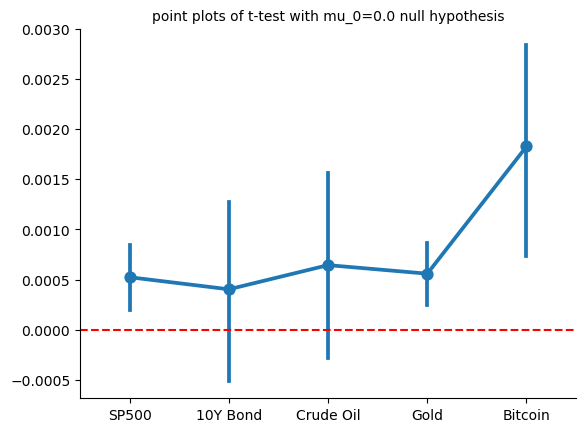

In [7]:
asset_1ttest_plots = plots_1ttest(asset_return_df, 0.0)

In [8]:
print('asset_return_2ttest_equal')
display(asset_return_2ttest_equal)

print('asset_return_2ttest_greater')
display(asset_return_2ttest_greater)

print('asset_return_2ttest_less')
display(asset_return_2ttest_less)


asset_return_2ttest_equal


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10,p-val
Bitcoin_SP500,2.3065,8460,two-sided,0.0211,"[0.0, 0.0]",0.0501,0.6354,0.349,0.0211
SP500_Bitcoin,-2.3065,8460,two-sided,0.0211,"[-0.0, -0.0]",0.0501,0.6354,0.349,0.0211
Bitcoin_Gold,2.2537,8460,two-sided,0.0242,"[0.0, 0.0]",0.0490,0.6154,0.309,0.0242
Gold_Bitcoin,-2.2537,8460,two-sided,0.0242,"[-0.0, -0.0]",0.0490,0.6154,0.309,0.0242
Bitcoin_10Y Bond,2.0345,8460,two-sided,0.0419,"[0.0, 0.0]",0.0442,0.5297,0.193,0.0419
10Y Bond_Bitcoin,-2.0345,8460,two-sided,0.0419,"[-0.0, -0.0]",0.0442,0.5297,0.193,0.0419
Bitcoin_Crude Oil,1.6608,8460,two-sided,0.0968,"[-0.0, 0.0]",0.0361,0.3825,0.097,0.0968
Crude Oil_Bitcoin,-1.6608,8460,two-sided,0.0968,"[-0.0, 0.0]",0.0361,0.3825,0.097,0.0968
Crude Oil_10Y Bond,0.3735,8460,two-sided,0.7088,"[-0.0, 0.0]",0.0081,0.0661,0.026,0.7088
10Y Bond_Crude Oil,-0.3735,8460,two-sided,0.7088,"[-0.0, 0.0]",0.0081,0.0661,0.026,0.7088


asset_return_2ttest_greater


,T,dof,alternative,p_val,CI95,cohen_d,power,p-val
Bitcoin_SP500,2.3065,8460,greater,0.0106,"[0.0, inf]",0.0501,0.7458,0.0106
Bitcoin_Gold,2.2537,8460,greater,0.0121,"[0.0, inf]",0.0490,0.7286,0.0121
Bitcoin_10Y Bond,2.0345,8460,greater,0.0210,"[0.0, inf]",0.0442,0.6515,0.0210
Bitcoin_Crude Oil,1.6608,8460,greater,0.0484,"[0.0, inf]",0.0361,0.5063,0.0484
Crude Oil_10Y Bond,0.3735,8460,greater,0.3544,"[-0.0, inf]",0.0081,0.1018,0.3544
Gold_10Y Bond,0.3277,8460,greater,0.3716,"[-0.0, inf]",0.0071,0.0939,0.3716
SP500_10Y Bond,0.2518,8460,greater,0.4006,"[-0.0, inf]",0.0055,0.0818,0.4006
Crude Oil_SP500,0.2432,8460,greater,0.4039,"[-0.0, inf]",0.0053,0.0805,0.4039
Crude Oil_Gold,0.1729,8460,greater,0.4314,"[-0.0, inf]",0.0038,0.0705,0.4314
Gold_SP500,0.1503,8460,greater,0.4402,"[-0.0, inf]",0.0033,0.0675,0.4402


asset_return_2ttest_less


,T,dof,alternative,p_val,CI95,cohen_d,power,p-val
SP500_Bitcoin,-2.3065,8460,less,0.0106,"[-inf, -0.0]",0.0501,0.7458,0.0106
Gold_Bitcoin,-2.2537,8460,less,0.0121,"[-inf, -0.0]",0.0490,0.7286,0.0121
10Y Bond_Bitcoin,-2.0345,8460,less,0.0210,"[-inf, -0.0]",0.0442,0.6515,0.0210
Crude Oil_Bitcoin,-1.6608,8460,less,0.0484,"[-inf, -0.0]",0.0361,0.5063,0.0484
10Y Bond_Crude Oil,-0.3735,8460,less,0.3544,"[-inf, 0.0]",0.0081,0.1018,0.3544
10Y Bond_Gold,-0.3277,8460,less,0.3716,"[-inf, 0.0]",0.0071,0.0939,0.3716
10Y Bond_SP500,-0.2518,8460,less,0.4006,"[-inf, 0.0]",0.0055,0.0818,0.4006
SP500_Crude Oil,-0.2432,8460,less,0.4039,"[-inf, 0.0]",0.0053,0.0805,0.4039
Gold_Crude Oil,-0.1729,8460,less,0.4314,"[-inf, 0.0]",0.0038,0.0705,0.4314
SP500_Gold,-0.1503,8460,less,0.4402,"[-inf, 0.0]",0.0033,0.0675,0.4402


In [9]:
# # Please enter you code for the funtion calls.
# I provide fully functional sample code here, but I expect you come up with your own code.

# dataframe of sample return
sample_list_stratified = asset_return_stratified(asset_return_df, ticker='SP500')

# dataframe of sample descriptive statistics
sample_list_des_stats = sample_list_stratified.apply(sample_des_stats)

ticker='SP500'
mu_0 = asset_return_df[ticker].mean()

# dataframe of 1-sample t-test for population mean
## welch test is needed as samples don't have the same size
sample_return_1ttest_equal = sample_list_stratified.apply(lambda x: asset_1ttest(x, mu_0, 'two-sided', True), axis=0) # 2-tail
sample_return_1ttest_greater = sample_list_stratified.apply(lambda x: asset_1ttest(x, mu_0, 'greater', True), axis=0) # 1-tail-right
sample_return_1ttest_less = sample_list_stratified.apply(lambda x: asset_1ttest(x, mu_0, 'less', True), axis=0) # 1-tail-left

# dataframe of 2-sample t-test for two means
## welch test is needed as samples don't have the same size
sample_return_2ttest_equal = asset_2ttest(sample_list_stratified, 'two-sided', True) # 2-tail
sample_return_2ttest_greater = asset_2ttest(sample_list_stratified, 'greater', True) # 1-tail-right
sample_return_2ttest_less = asset_2ttest(sample_list_stratified, 'less', True) # 1-tail-left


In [10]:
print('sample_list_stratified')
display(sample_list_stratified)

print('sample_list_des_stats')
display(sample_list_des_stats)


sample_list_stratified


,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,-0.013249,0.001974,0.007968,0.003705,0.003641,-0.012258,0.005293,0.011491,-0.015067,-0.002710
1,0.000005,0.014315,0.007968,0.003874,-0.000397,-0.017903,-0.009578,0.011491,-0.015067,0.000079
2,0.011166,0.014315,-0.003261,0.002159,0.000712,0.007972,-0.009578,0.011491,0.025884,-0.013744
3,0.011166,0.014315,-0.004956,0.001247,-0.008169,0.014217,-0.009578,-0.012986,0.030584,0.008110
4,0.011166,0.018290,0.004297,0.005647,-0.005528,0.014217,0.017973,0.010525,-0.002018,-0.001304
...,...,...,...,...,...,...,...,...,...,...
361,-0.000466,-0.008588,0.004085,0.002763,-0.005316,0.015977,-0.002776,-0.002120,0.000229,0.004039
362,-0.025666,0.006444,0.001205,-0.000007,-0.005316,0.015977,-0.020364,0.019672,0.005893,-0.001253
363,0.001233,0.005297,0.003705,-0.000007,-0.005316,0.016111,0.001569,-0.021126,-0.002710,-0.001253
364,0.019076,-0.009321,0.003705,-0.000007,0.005048,-0.004813,-0.011910,-0.015067,-0.002710,-0.001253


sample_list_des_stats


,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,365.000000,366.000000,365.000000,365.000000,365.000000,366.000000,365.000000,365.000000,365.000000,366.000000
mean,-0.000307,0.000247,0.000652,0.000879,-0.000031,0.000986,0.001316,-0.000739,0.001039,0.001310
std,0.009432,0.009896,0.004245,0.007867,0.010694,0.020277,0.008426,0.014105,0.010739,0.007760
min,-0.039414,-0.035920,-0.018178,-0.040979,-0.032864,-0.119841,-0.035288,-0.043237,-0.028004,-0.029969
25%,-0.005090,-0.003756,-0.001582,-0.002213,-0.005262,-0.005401,-0.003396,-0.009244,-0.005300,-0.002777
50%,-0.000119,0.000048,0.000482,0.000944,0.000676,0.002354,0.001447,-0.000777,0.000155,0.001224
75%,0.004570,0.004750,0.002923,0.005072,0.006411,0.008151,0.007373,0.008298,0.006978,0.006115
max,0.039034,0.024760,0.022224,0.027157,0.049594,0.093828,0.023791,0.030563,0.055434,0.023043
skewness,-0.319788,-0.397568,0.010458,-1.084230,-0.238244,-0.058747,-0.404352,-0.275987,0.414725,-0.452462
kurtosis,1.960613,1.242584,3.557556,4.452618,2.321839,9.341365,1.012808,0.130854,1.700551,0.813336


In [11]:
print('sample_return_1ttest_equal')
display(sample_return_1ttest_equal)

print('sample_return_1ttest_greater')
display(sample_return_1ttest_greater)

print('sample_return_1ttest_less')
display(sample_return_1ttest_less)


sample_return_1ttest_equal


,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
mu_null,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524
mu_alternative,-0.000307,0.000247,0.000652,0.000879,-0.000031,0.000986,0.001316,-0.000739,0.001039,0.00131
T,-1.6823,-0.5352,0.5776,0.8642,-0.9905,0.4367,1.7971,-1.7096,0.9172,1.9377
dof,364,365,364,364,364,365,364,364,364,365
alternative,two-sided,two-sided,two-sided,two-sided,two-sided,two-sided,two-sided,two-sided,two-sided,two-sided
p_val,0.0934,0.5928,0.5639,0.3881,0.3226,0.6626,0.0732,0.0882,0.3597,0.0534
CI95,"[-0.0, 0.0]","[-0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[-0.0, 0.0]","[-0.0, 0.0]","[0.0, 0.0]","[-0.0, 0.0]","[-0.0, 0.0]","[0.0, 0.0]"
cohen_d,0.0881,0.028,0.0302,0.0452,0.0518,0.0228,0.0941,0.0895,0.048,0.1013
power,0.3891,0.0832,0.0888,0.1385,0.1671,0.072,0.4335,0.3995,0.15,0.4891
BF10,0.238,0.068,0.069,0.085,0.096,0.064,0.29,0.249,0.089,0.374


sample_return_1ttest_greater


,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
mu_null,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524
mu_alternative,-0.000307,0.000247,0.000652,0.000879,-0.000031,0.000986,0.001316,-0.000739,0.001039,0.00131
T,-1.6823,-0.5352,0.5776,0.8642,-0.9905,0.4367,1.7971,-1.7096,0.9172,1.9377
dof,364,365,364,364,364,365,364,364,364,365
alternative,greater,greater,greater,greater,greater,greater,greater,greater,greater,greater
p_val,0.9533,0.7036,0.2819,0.194,0.8387,0.3313,0.0366,0.9559,0.1798,0.0267
CI95,"[-0.0, inf]","[-0.0, inf]","[0.0, inf]","[0.0, inf]","[-0.0, inf]","[-0.0, inf]","[0.0, inf]","[-0.0, inf]","[0.0, inf]","[0.0, inf]"
cohen_d,0.0881,0.028,0.0302,0.0452,0.0518,0.0228,0.0941,0.0895,0.048,0.1013
power,0.0004,0.0147,0.1427,0.217,0.0042,0.1133,0.5592,0.0004,0.2329,0.6138


sample_return_1ttest_less


,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
mu_null,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524,0.000524
mu_alternative,-0.000307,0.000247,0.000652,0.000879,-0.000031,0.000986,0.001316,-0.000739,0.001039,0.00131
T,-1.6823,-0.5352,0.5776,0.8642,-0.9905,0.4367,1.7971,-1.7096,0.9172,1.9377
dof,364,365,364,364,364,365,364,364,364,365
alternative,less,less,less,less,less,less,less,less,less,less
p_val,0.0467,0.2964,0.7181,0.806,0.1613,0.6687,0.9634,0.0441,0.8202,0.9733
CI95,"[-inf, 0.0]","[-inf, 0.0]","[-inf, 0.0]","[-inf, 0.0]","[-inf, 0.0]","[-inf, 0.0]","[-inf, 0.0]","[-inf, 0.0]","[-inf, 0.0]","[-inf, 0.0]"
cohen_d,0.0881,0.028,0.0302,0.0452,0.0518,0.0228,0.0941,0.0895,0.048,0.1013
power,0.5137,0.1334,0.0132,0.0061,0.2559,0.0187,0.0003,0.5245,0.0052,0.0002


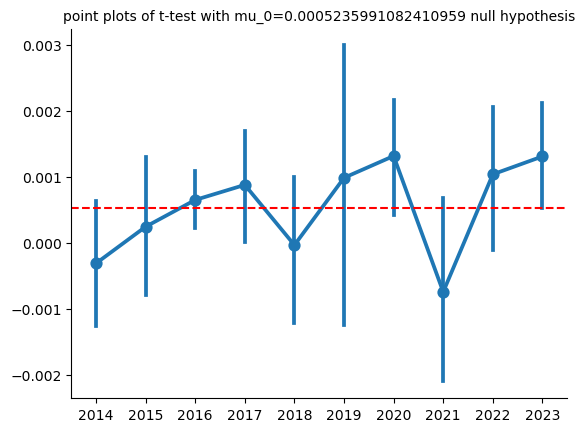

In [12]:
sample_1ttest_plots = plots_1ttest(sample_list_stratified, mu_0=mu_0)

In [13]:
print('sample_return_2ttest_equal')
display(sample_return_2ttest_equal)

print('sample_return_2ttest_greater')
display(sample_return_2ttest_greater)

print('sample_return_2ttest_less')
display(sample_return_2ttest_less)


sample_return_2ttest_equal


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10,p-val
2023_2014,2.5299,702.2003,two-sided,0.0116,"[0.0, 0.0]",0.1872,0.7148,1.882,0.0116
2014_2023,-2.5299,702.2003,two-sided,0.0116,"[-0.0, -0.0]",0.1872,0.7148,1.882,0.0116
2020_2014,2.4519,718.9359,two-sided,0.0144,"[0.0, 0.0]",0.1815,0.6875,1.558,0.0144
2014_2020,-2.4519,718.9359,two-sided,0.0144,"[-0.0, -0.0]",0.1815,0.6875,1.558,0.0144
2023_2021,2.4313,565.5352,two-sided,0.0154,"[0.0, 0.0]",0.1800,0.6808,1.483,0.0154
...,...,...,...,...,...,...,...,...,...
2017_2019,-0.0941,472.7049,two-sided,0.9251,"[-0.0, 0.0]",0.0070,0.0510,0.083,0.9251
2022_2019,0.0439,555.1591,two-sided,0.9650,"[-0.0, 0.0]",0.0032,0.0502,0.083,0.9650
2019_2022,-0.0439,555.1591,two-sided,0.9650,"[-0.0, 0.0]",0.0032,0.0502,0.083,0.9650
2020_2023,0.0111,723.7836,two-sided,0.9912,"[-0.0, 0.0]",0.0008,0.0500,0.083,0.9912


sample_return_2ttest_greater


,T,dof,alternative,p_val,CI95,cohen_d,power,p-val
2023_2014,2.5299,702.2003,greater,0.0058,"[0.0, inf]",0.1872,0.8115,0.0058
2020_2014,2.4519,718.9359,greater,0.0072,"[0.0, inf]",0.1815,0.7895,0.0072
2023_2021,2.4313,565.5352,greater,0.0077,"[0.0, inf]",0.1800,0.7841,0.0077
2020_2021,2.3893,594.4605,greater,0.0086,"[0.0, inf]",0.1769,0.7710,0.0086
2023_2018,1.9391,664.0571,greater,0.0265,"[0.0, inf]",0.1435,0.6153,0.0265
...,...,...,...,...,...,...,...,...
2018_2023,-1.9391,664.0571,greater,0.9735,"[-0.0, inf]",0.1435,0.0002,0.9735
2021_2020,-2.3893,594.4605,greater,0.9914,"[-0.0, inf]",0.1769,0.0000,0.9914
2021_2023,-2.4313,565.5352,greater,0.9923,"[-0.0, inf]",0.1800,0.0000,0.9923
2014_2020,-2.4519,718.9359,greater,0.9928,"[-0.0, inf]",0.1815,0.0000,0.9928


sample_return_2ttest_less


,T,dof,alternative,p_val,CI95,cohen_d,power,p-val
2014_2023,-2.5299,702.2003,less,0.0058,"[-inf, -0.0]",0.1872,0.8115,0.0058
2014_2020,-2.4519,718.9359,less,0.0072,"[-inf, -0.0]",0.1815,0.7895,0.0072
2021_2023,-2.4313,565.5352,less,0.0077,"[-inf, -0.0]",0.1800,0.7841,0.0077
2021_2020,-2.3893,594.4605,less,0.0086,"[-inf, -0.0]",0.1769,0.7710,0.0086
2018_2023,-1.9391,664.0571,less,0.0265,"[-inf, -0.0]",0.1435,0.6153,0.0265
...,...,...,...,...,...,...,...,...
2023_2018,1.9391,664.0571,less,0.9735,"[-inf, 0.0]",0.1435,0.0002,0.9735
2020_2021,2.3893,594.4605,less,0.9914,"[-inf, 0.0]",0.1769,0.0000,0.9914
2023_2021,2.4313,565.5352,less,0.9923,"[-inf, 0.0]",0.1800,0.0000,0.9923
2020_2014,2.4519,718.9359,less,0.9928,"[-inf, 0.0]",0.1815,0.0000,0.9928


In [14]:
# # Please enter you code for the funtion calls.
# I provide fully functional sample code here, but I expect you come up with your own code.

asset_ret_anova = asset_return_anova(asset_return_df, p_threshold=0.01)
asset_ret_pairwise_equal = asset_return_pairwise(asset_return_df, asset_ret_anova['p-unc'].iloc[0], 0.05, 'two-sided')
asset_ret_pairwise_greater = asset_return_pairwise(asset_return_df, asset_ret_anova['p-unc'].iloc[0], 0.05, 'greater')
asset_ret_pairwise_less = asset_return_pairwise(asset_return_df, asset_ret_anova['p-unc'].iloc[0], 0.05, 'less')


levene test p_value is 0.0, homoscedasticity does not hold, use welch anova.

p_value of anova test is 0.2272252699535498, larger than 0.05, no pairwise test is conducted.
p_value of anova test is 0.2272252699535498, larger than 0.05, no pairwise test is conducted.
p_value of anova test is 0.2272252699535498, larger than 0.05, no pairwise test is conducted.


In [15]:
print('asset_ret_anova')
display(asset_ret_anova)

print('asset_ret_pairwise_equal')
display(asset_ret_pairwise_equal)

print('asset_ret_pairwise_greater')
display(asset_ret_pairwise_greater)

print('asset_ret_pairwise_less')
display(asset_ret_pairwise_less)


asset_ret_anova


,Source,ddof1,ddof2,F,p_unc,np2,p-unc
0,asset,4,10048.095611,1.411654,0.227225,0.000425,0.227225


asset_ret_pairwise_equal


None

asset_ret_pairwise_greater


None

asset_ret_pairwise_less


None

In [16]:
sample_ret_anova = asset_return_anova(sample_list_stratified)
sample_ret_pairwise_equal = asset_return_pairwise(sample_list_stratified, sample_ret_anova['p-unc'].iloc[0], 0.10, 'two-sided')
sample_ret_pairwise_greater = asset_return_pairwise(sample_list_stratified, sample_ret_anova['p-unc'].iloc[0], 0.10, 'greater')
sample_ret_pairwise_less = asset_return_pairwise(sample_list_stratified, sample_ret_anova['p-unc'].iloc[0], 0.10, 'less')


levene test p_value is 0.0, homoscedasticity does not hold, use welch anova.



In [17]:
print('sample_ret_anova')
display(sample_ret_anova)

print('sample_ret_pairwise_equal')
display(sample_ret_pairwise_equal)

print('sample_ret_pairwise_greater')
display(sample_ret_pairwise_greater)

print('sample_ret_pairwise_less')
display(sample_ret_pairwise_less)


sample_ret_anova


,Source,ddof1,ddof2,F,p_unc,np2,p-unc
0,asset,9,1467.745864,1.682472,0.088211,0.003657,0.088211


sample_ret_pairwise_equal


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges,p-unc,p-corr
8,asset,2014,2023,False,True,-2.529945,702.200264,two-sided,0.011626,0.523151,holm,1.882,-0.187004,0.011626,0.523151
5,asset,2014,2020,False,True,-2.451865,728.000000,two-sided,0.014446,0.635608,holm,1.558,-0.181308,0.014446,0.635608
43,asset,2021,2023,False,True,-2.431345,565.535226,two-sided,0.015352,0.660155,holm,1.483,-0.179800,0.015352,0.660155
39,asset,2020,2021,False,True,2.389250,728.000000,two-sided,0.017136,0.719729,holm,1.344,0.176678,0.017136,0.719729
34,asset,2018,2023,False,True,-1.939084,664.057137,two-sided,0.052914,1.000000,holm,0.52,-0.143353,0.052914,1.000000
42,asset,2021,2022,False,True,-1.915790,728.000000,two-sided,0.055783,1.000000,holm,0.498,-0.141667,0.055783,1.000000
27,asset,2017,2021,False,True,1.913960,728.000000,two-sided,0.056017,1.000000,holm,0.496,0.141532,0.056017,1.000000
31,asset,2018,2020,False,True,-1.890262,728.000000,two-sided,0.059120,1.000000,holm,0.475,-0.139779,0.059120,1.000000
2,asset,2014,2017,False,True,-1.845440,728.000000,two-sided,0.065379,1.000000,holm,0.437,-0.136465,0.065379,1.000000
21,asset,2016,2021,False,True,1.803487,728.000000,two-sided,0.071725,1.000000,holm,0.406,0.133363,0.071725,1.000000


sample_ret_pairwise_greater


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,hedges,p-unc,p-corr
39,asset,2020,2021,False,True,2.389250,728.000000,greater,0.008568,0.385569,holm,0.176678,0.008568,0.385569
27,asset,2017,2021,False,True,1.913960,728.000000,greater,0.028009,1.000000,holm,0.141532,0.028009,1.000000
21,asset,2016,2021,False,True,1.803487,728.000000,greater,0.035863,1.000000,holm,0.133363,0.035863,1.000000
36,asset,2019,2021,False,True,1.335454,651.357218,greater,0.091097,1.000000,holm,0.098638,0.091097,1.000000
24,asset,2017,2018,False,True,1.309977,728.000000,greater,0.095308,1.000000,holm,0.096869,0.095308,1.000000
18,asset,2016,2018,False,True,1.133779,728.000000,greater,0.128630,1.000000,holm,0.083840,0.128630,1.000000
14,asset,2015,2021,False,True,1.093009,652.314024,greater,0.137397,1.000000,holm,0.080807,0.137397,1.000000
32,asset,2018,2021,False,True,0.763831,728.000000,greater,0.222608,1.000000,holm,0.056483,0.222608,1.000000
6,asset,2014,2021,False,True,0.485926,728.000000,greater,0.313583,1.000000,holm,0.035933,0.313583,1.000000
40,asset,2020,2022,False,True,0.387745,728.000000,greater,0.349159,1.000000,holm,0.028673,0.349159,1.000000


sample_ret_pairwise_less


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,hedges,p-unc,p-corr
8,asset,2014,2023,False,True,-2.529945,702.200264,less,0.005813,0.261576,holm,-0.187004,0.005813,0.261576
5,asset,2014,2020,False,True,-2.451865,728.000000,less,0.007223,0.317804,holm,-0.181308,0.007223,0.317804
43,asset,2021,2023,False,True,-2.431345,565.535226,less,0.007676,0.330077,holm,-0.179800,0.007676,0.330077
34,asset,2018,2023,False,True,-1.939084,664.057137,less,0.026457,1.000000,holm,-0.143353,0.026457,1.000000
42,asset,2021,2022,False,True,-1.915790,728.000000,less,0.027892,1.000000,holm,-0.141667,0.027892,1.000000
31,asset,2018,2020,False,True,-1.890262,728.000000,less,0.029560,1.000000,holm,-0.139779,0.029560,1.000000
2,asset,2014,2017,False,True,-1.845440,728.000000,less,0.032690,1.000000,holm,-0.136465,0.032690,1.000000
7,asset,2014,2022,False,True,-1.799308,728.000000,less,0.036192,1.000000,holm,-0.133054,0.036192,1.000000
1,asset,2014,2016,False,True,-1.771178,728.000000,less,0.038475,1.000000,holm,-0.130973,0.038475,1.000000
16,asset,2015,2023,False,True,-1.616847,730.000000,less,0.053172,1.000000,holm,-0.119398,0.053172,1.000000
